# Biblioteka Seaborn

Seaborn to biblioteka wykorzystywana do statystycznych wizualizacji danych. Została zbudowana na bazie biblioteki matplotlib i jednocześnie została zintegrowana do struktur danych udostępnianych przez bibliotekę pandas. 

In [2]:
import seaborn as sns

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
athlete_events = pd.read_csv('athlete_events.csv', sep=';')

athlete_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


--------------------
### Wykresy relacyjne

Wykresy relacyjne przedstawiają relacje pomiędzy danymi. Funkcja `relplot` znajduje się na poziomie *figure* (poziom wyższy) i korzysta z funkcji z poziomu *axes* (poziom niższy): `scatterplot` oraz `lineplot`. Do wizualizacji danych można wykorzystywać wszystkie powyższe funkcje z odpowiednimi parametrami.

##### ⭐ Zadanie 1: 

Przygotuj wykres punktowy (`scatterplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z funkcjami `set_theme` i `set_style` oraz ich parametrami. Wykorzystaj je, żeby dostosować wygląd swojego wykresu. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

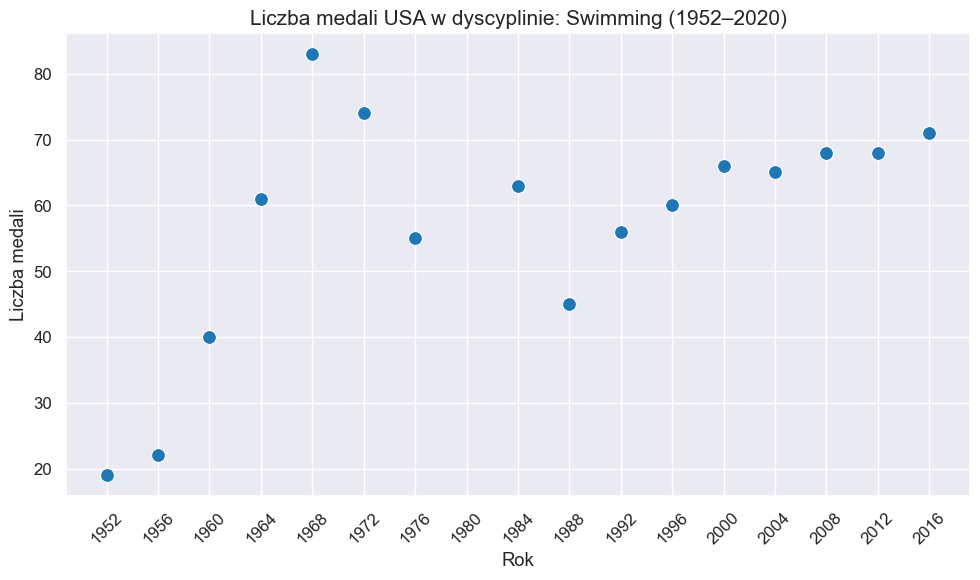

In [20]:

usa_medals = athlete_events.loc[
    (athlete_events['NOC'] == 'USA') &
    (athlete_events['Year'] >= 1950) &
    (athlete_events['Year'] <= 2017) &
    (athlete_events['Medal'].notna())
]

top_sport = (
    usa_medals.groupby('Sport')['Medal']
    .count()
    .sort_values(ascending=False)
    .idxmax()
)

top_sport_data = usa_medals[usa_medals['Sport'] == top_sport]

medals_per_year = top_sport_data.groupby('Year').size().reset_index(name='Medal Count')

sns.set_theme(
    style="darkgrid",
    palette="deep",
    font="sans-serif",
    font_scale=1.1
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=medals_per_year,
    x='Year',
    y='Medal Count',
    color='#1f77b4',
    s=100
)

ax.set_xticks(range(1952, 2017, 4))


plt.title(f'Liczba medali USA w dyscyplinie: {top_sport} (1952–2020)', fontsize=15)
plt.xlabel('Rok')
plt.ylabel('Liczba medali')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# można jeszcze rozdzielić na medale zdobyte przez kobiety/mezczyzn lub zloto/srebro/braz ale nie wiem czy bedzie czytelnie na punktowym/ do rozwazenia przez HK xd

##### ⭐ Zadanie 2:

Przygotuj wykres liniowy (`lineplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `hue` oraz dobierz dla niego właściwą wartość mając na uwadze wizualizację określonej liczby serii danych. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i legenda). 

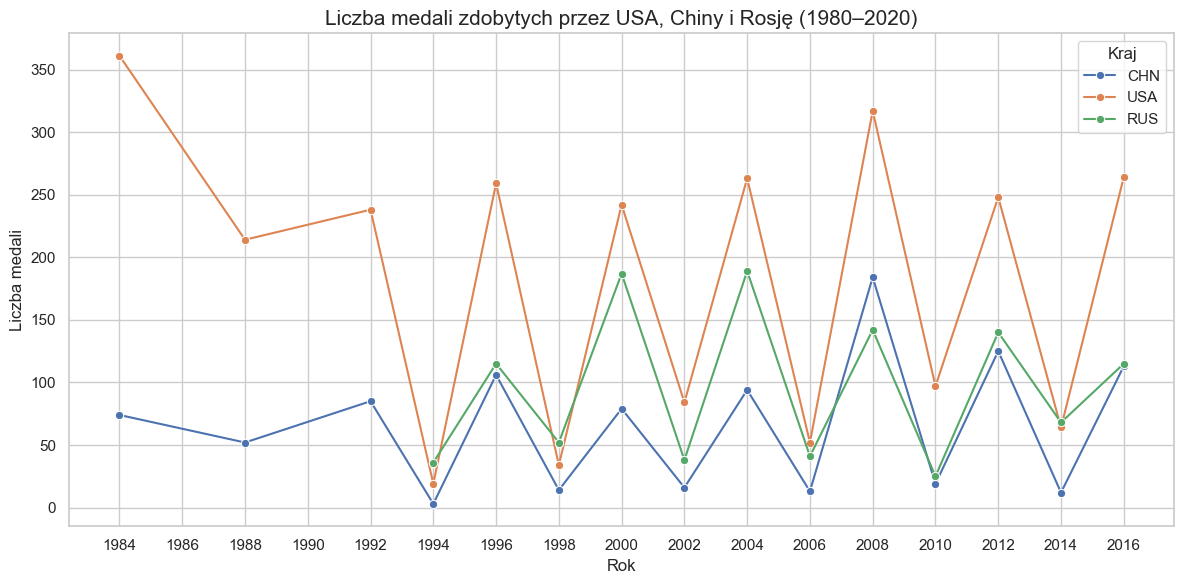

In [8]:
medals = athlete_events[
    athlete_events['Medal'].notna() &
    (athlete_events['NOC'].isin(['USA', 'CHN', 'RUS'])) &
    (athlete_events['Year'] >= 1984) &
    (athlete_events['Year'] <= 2017)
]

medal_counts = (
    medals.groupby(['Year', 'NOC'])
    .size()
    .reset_index(name='Medal Count')
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=medal_counts,
    x='Year',
    y='Medal Count',
    hue='NOC',
    marker='o'
)
ax.set_xticks(range(1984, 2017, 2))

plt.title('Liczba medali zdobytych przez USA, Chiny i Rosję (1980–2020)', fontsize=15)
plt.xlabel('Rok')
plt.ylabel('Liczba medali')

plt.legend(title='Kraj')
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 3:

Przygotuj wykres liniowy (`relplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych, gdzie każda seria danych będzie przedstawiona na osobnym podwykresie (`subplot`) jednego obrazu. Zapoznaj się z parametrami `row` i `col` oraz dobierz dla nich właściwą wartość mając na uwadze wizualizację określonej liczby serii danych na osobnych podwykresach. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i ewentualnie legenda). 

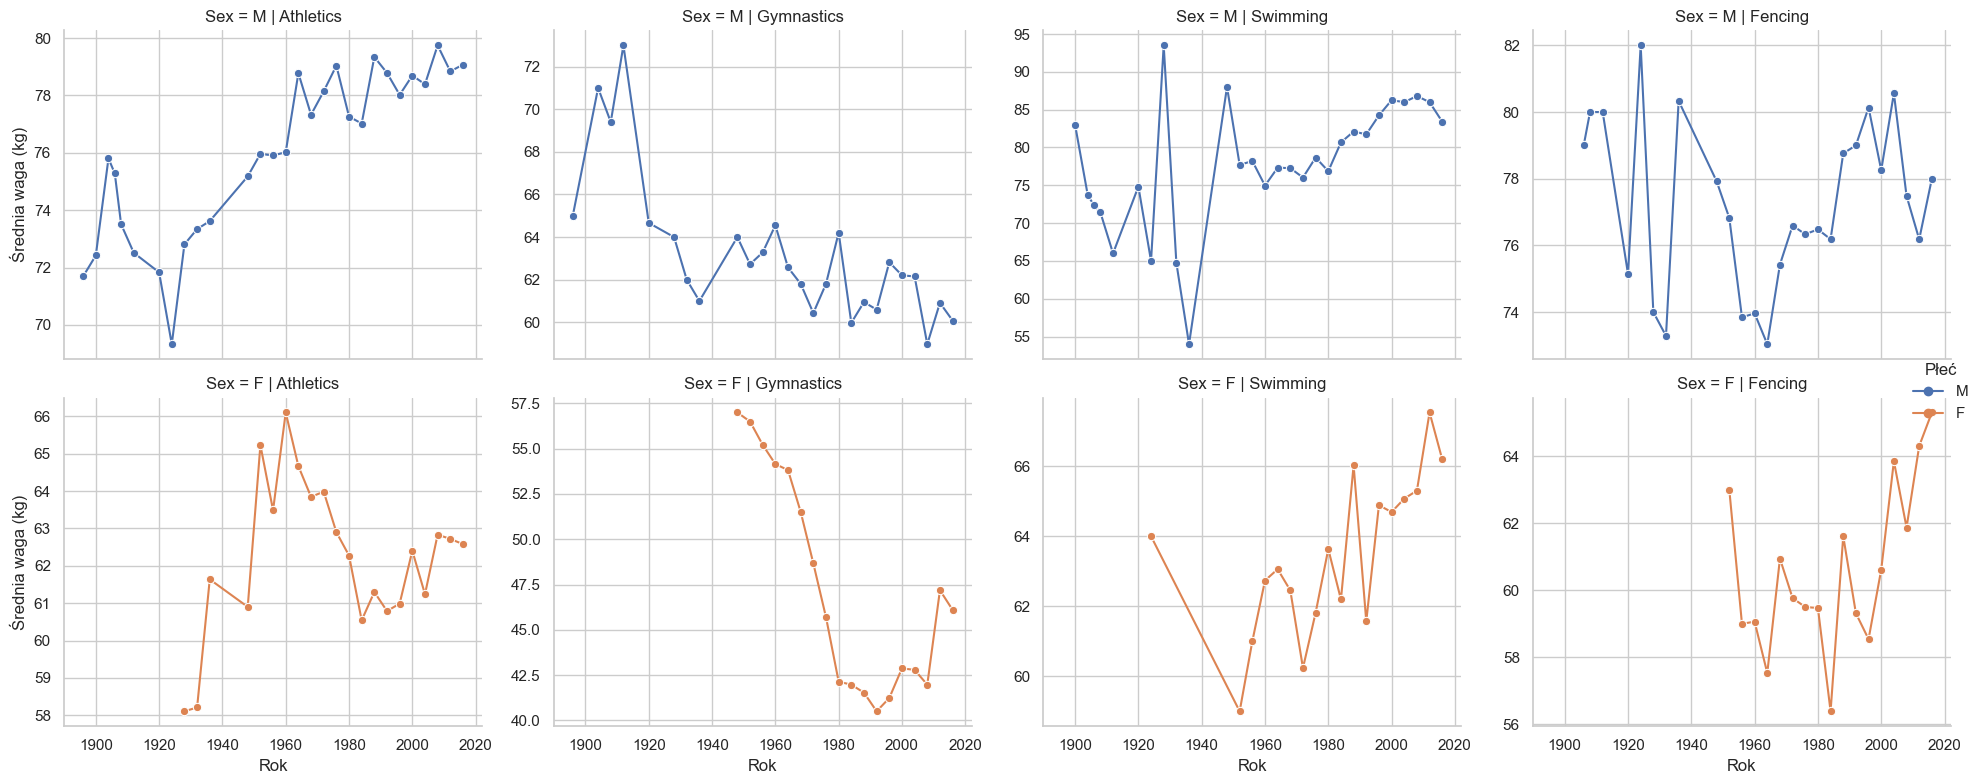

In [34]:

medals = athlete_events[
    athlete_events['Medal'].notna() &
    athlete_events['Weight'].notna() &
    athlete_events['Sex'].notna()
]

selected_sports = ['Athletics', 'Gymnastics', 'Fencing', 'Swimming']

filtered = medals[medals['Sport'].isin(selected_sports)]

grouped = (
    filtered.groupby(['Year', 'Sport', 'Sex'])['Weight']
    .mean()
    .reset_index()
)

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=grouped,
    x='Year',
    y='Weight',
    hue='Sex',
    col='Sport',
    row='Sex',
    kind='line',
    marker='o',
    facet_kws={'sharey': False},
    height=4,
    aspect=1.2
)

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Rok", "Średnia waga (kg)")
g._legend.set_title("Płeć")

plt.tight_layout()
plt.show()
# wybrac ktore maja najwiekszy potencjał/pobawic sie kolorami moze/ jakies fajerwerki niech beda

##### ⭐ Zadanie 4:

Przygotuj wykres bąbelkowy (`relplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Wykorzystaj rozmiary i kolory markerów do zaprezentowania większej liczby informacji. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i opis skali koloru). 

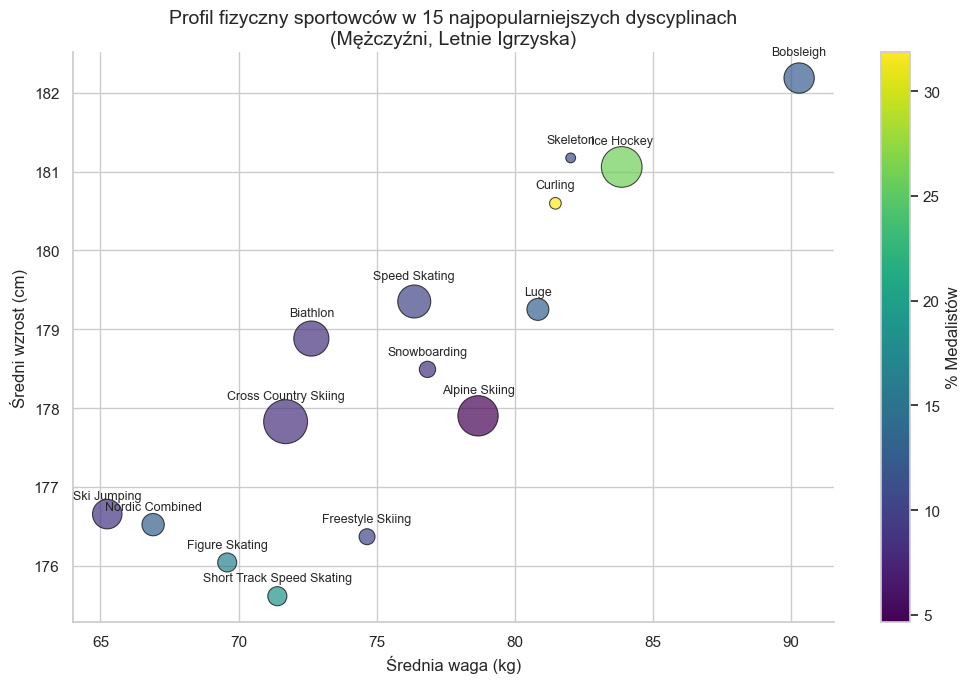

In [58]:

subset = athlete_events[
    (athlete_events['Sex'] == 'M') &
    (athlete_events['Season'] == 'Winter') &
    (athlete_events['Height'].notna()) &
    (athlete_events['Weight'].notna())
]

top_sports = (
    subset.groupby('Sport')
    .agg({
        'Height': 'mean',
        'Weight': 'mean',
        'ID': 'count',
        'Medal': lambda x: x.notna().mean() * 100
    })
    .rename(columns={'ID': 'Count', 'Medal': '% Medalists'})
    .sort_values(by='Count', ascending=False)
    .head(20)
    .reset_index()
)

bubble = sns.relplot(
    data=top_sports,
    x='Weight',
    y='Height',
    size='Count',
    hue='% Medalists',
    palette='viridis',
    sizes=(50, 1000),
    alpha=0.7,
    marker='o',
    edgecolor='black',
    height=7,
    aspect=1.5,
    legend=False
)

for i in range(top_sports.shape[0]):
    count = top_sports['Count'][i]
    offset = 0.15 if count < 2000 else 0.25

    plt.text(
        top_sports['Weight'][i],
        top_sports['Height'][i] + offset,
        top_sports['Sport'][i],
        fontsize=9,
        ha='center',
        va='bottom'
    )

sc = plt.scatter(
    top_sports['Weight'],
    top_sports['Height'],
    c=top_sports['% Medalists'],
    cmap='viridis',
    s=0
)
cbar = plt.colorbar(sc)
cbar.set_label('% Medalistów')

bubble.set_axis_labels("Średnia waga (kg)", "Średni wzrost (cm)")
plt.title("Profil fizyczny sportowców w 15 najpopularniejszych dyscyplinach\n(Mężczyźni, Letnie Igrzyska)", fontsize=14)

plt.tight_layout()
plt.show()

--------------------
### Wykresy dystrybucji

Wykresy dystrybucji przedstawiają w jawny sposób rozkład danych. Funkcja `displot` znajduje się na poziomie *figure* (poziom wyższy) i korzysta z funkcji z poziomu *axes* (poziom niższy): `histplot`, `kdeplot`, `ecdfplot` oraz `rugplot`. Do wizualizacji danych można wykorzystywać wszystkie powyższe funkcje z odpowiednimi parametrami.

##### ⭐ Zadanie 5:

Przygotuj histogram (`displot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zapoznaj się z parametrami `bins` i `binwidth` oraz dobierz dla nich takie wartości, które wg. Ciebie najlepiej wizualizują dane. Zadbaj o czytelność wykresu (tytuł wykresu oraz podpisy osi). 

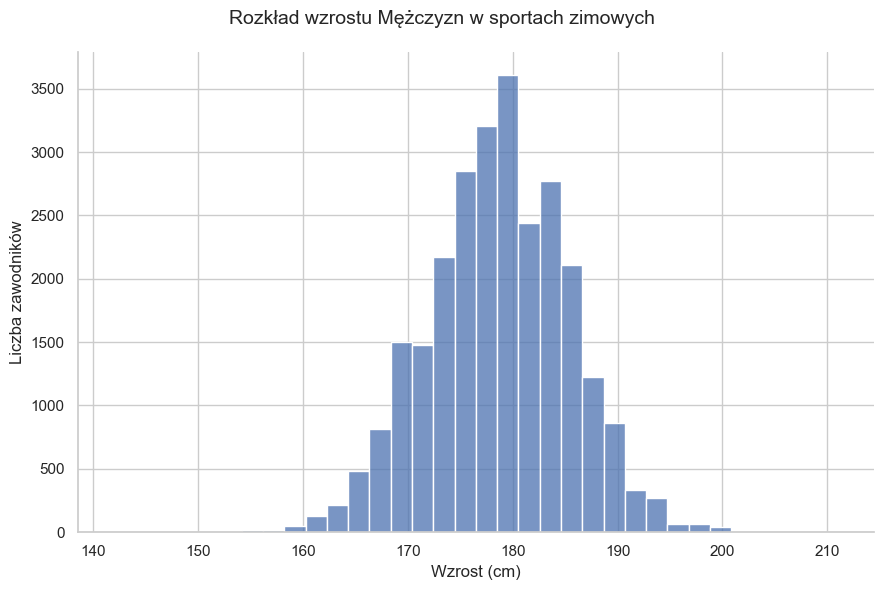

In [6]:
winter_height = athlete_events[
    (athlete_events['Season'] == 'Winter') &
    (athlete_events['Height'].notna()) &
    (athlete_events['Sex'] == 'M')
]

sns.set_theme(style="whitegrid")

g = sns.displot(
    data=winter_height,
    x='Height',
    kind='hist',
    binwidth=2,
    height=6,
    aspect=1.5,
    multiple='stack'
)

g.set_axis_labels("Wzrost (cm)", "Liczba zawodników")
g.fig.suptitle("Rozkład wzrostu Mężczyzn w sportach zimowych", fontsize=14)
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 6:

Przedstaw na wykresie dystrybucji (`displot`) jądrowy estymator gęstości (`kde`) oraz dystrybuantę empiryczną (`ecdf`) dla danych, które wg. Ciebie najlepiej pokażą ich zastosowanie. Każdy rodzaj wykresu dystrybucji musi być przedstawiony na osobnym podwykresie (`subplot`) jednego obrazu. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi i ewentualnie legenda). 

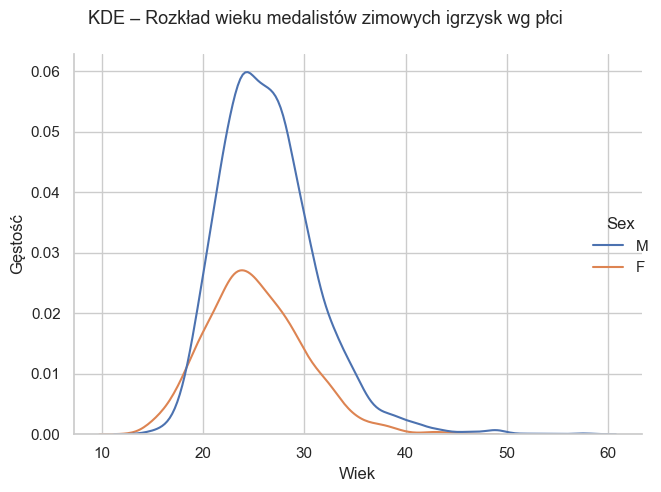

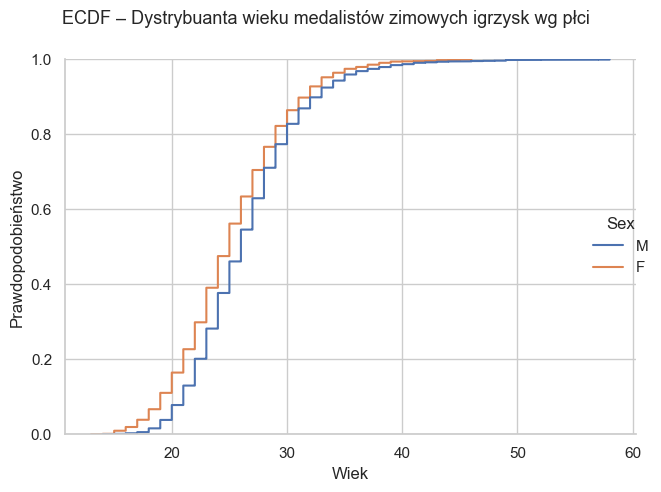

In [7]:
winter_medalists_age = athlete_events[
    (athlete_events['Season'] == 'Winter') &
    (athlete_events['Medal'].notna()) &
    (athlete_events['Age'].notna()) &
    (athlete_events['Sex'].isin(['M', 'F']))
]

sns.set_theme(style="whitegrid")

g = sns.displot(
    data=winter_medalists_age,
    x='Age',
    hue='Sex',
    kind='kde',
    height=5,
    aspect=1.2,
)

g.fig.suptitle("KDE – Rozkład wieku medalistów zimowych igrzysk wg płci", fontsize=13)
g.set_axis_labels("Wiek", "Gęstość")
plt.tight_layout()
plt.show()

g2 = sns.displot(
    data=winter_medalists_age,
    x='Age',
    hue='Sex',
    kind='ecdf',
    height=5,
    aspect=1.2
)

g2.fig.suptitle("ECDF – Dystrybuanta wieku medalistów zimowych igrzysk wg płci", fontsize=13)
g2.set_axis_labels("Wiek", "Prawdopodobieństwo")
plt.tight_layout()
plt.show()

##### ⭐ Zadanie 7:

Przygotuj dwuwymiarowy histogram (`displot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda). 

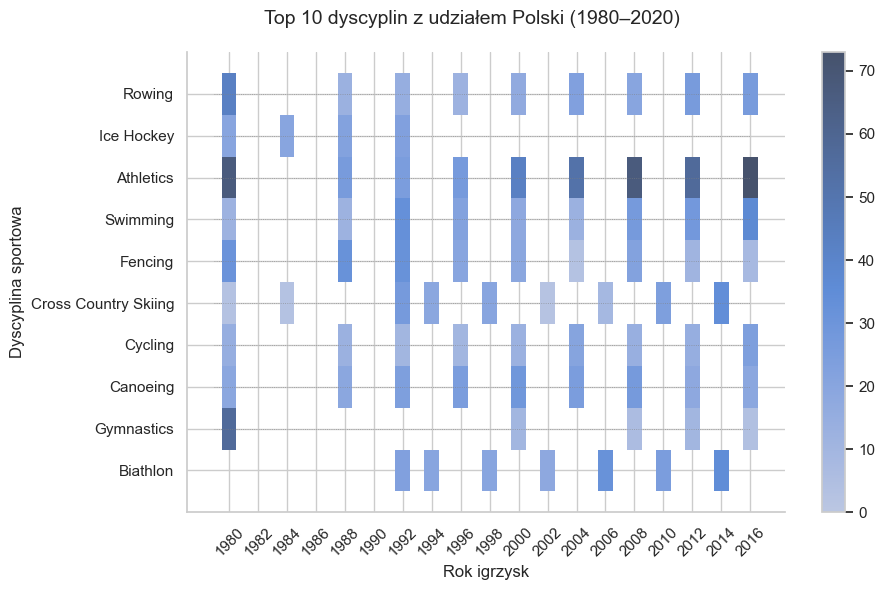

In [20]:
years_range = list(range(1980, 2021, 2))

top_10_sports_pol = (
    athlete_events[athlete_events['NOC'] == 'POL']
    .groupby('Sport')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
polish_top10_filtered = athlete_events[
    (athlete_events['NOC'] == 'POL') &
    (athlete_events['Sport'].isin(top_10_sports_pol)) &
    (athlete_events['Year'].isin(years_range))
]
sns.set_theme(style="whitegrid")

g = sns.displot(
    data=polish_top10_filtered,
    x='Year',
    y='Sport',
    kind='hist',
    discrete=(True, True),
    cbar=True,
    height=6,
    aspect=1.6
)

sports = sorted(polish_top10_filtered['Sport'].unique())
for i in range(len(sports) - 1):
    g.ax.hlines(
        y=i,
        xmin=1979, xmax=2016,
        colors='gray',
        linestyles='dotted',
        linewidth=0.6,
        alpha=0.7
    )

g.ax.set_xticks(range(1980, 2017, 2))


g.set_axis_labels("Rok igrzysk", "Dyscyplina sportowa")
g.fig.suptitle("Top 10 dyscyplin z udziałem Polski (1980–2020)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--------------------
### Wykresy dystrybucji +

Podstawowe typy wykresów dystrybucji mogą być dodatkowo rozszerzone o więcej informacji. Wizualizacja zależności 2 zmiennych może przedstawiać na marginesach wizualizacje rozkładu każdej zmiennej osobno. Przy wybraniu większej liczby zmiennych, możliwe jest wygenerowanie wszystkich kombinacji pomiędzy nimi. Służą do tego funkcje `jointplot` i `pairplot`, które znajdują się na poziomie *figure*.

##### ⭐ Zadanie 8:

Przygotuj wykres punktowy z rozkładem gęstości na osiach marginalnych (`jointplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z obiektem `plot_joint` i narysuj dodatkowo rozkład gęstości wartości na głównym wykresie punktowym. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda). 

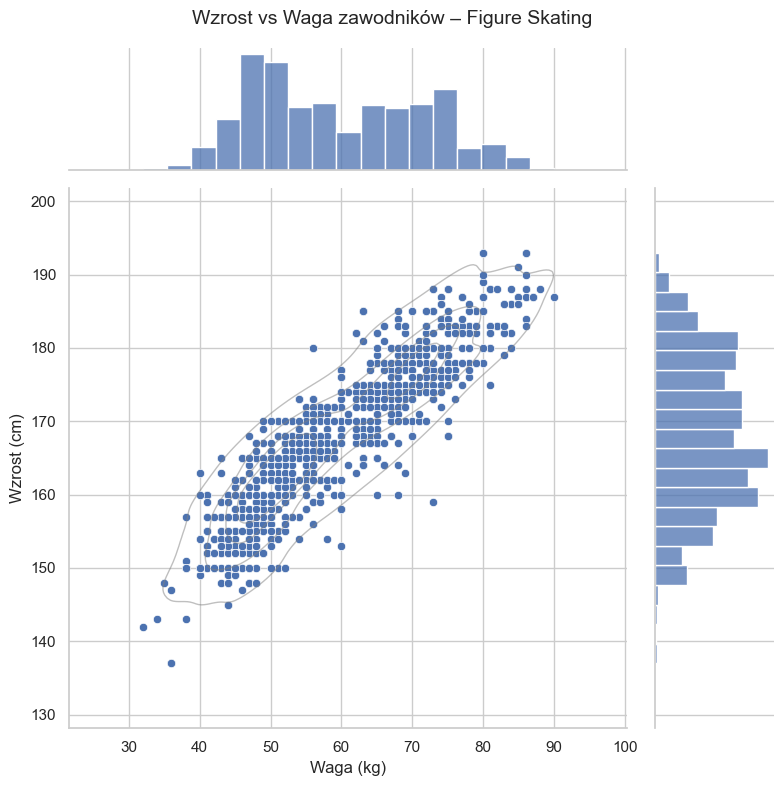

In [23]:

athlete_events['Height'] = pd.to_numeric(athlete_events['Height'], errors='coerce')
athlete_events['Weight'] = pd.to_numeric(athlete_events['Weight'], errors='coerce')

selected_sport = 'Figure Skating'

sport_subset = athlete_events[
    (athlete_events['Sport'] == selected_sport) &
    (athlete_events['Weight'].notna()) &
    (athlete_events['Height'].notna()) &
    (athlete_events['Sex'].notna())
].copy()

sns.set_theme(style="whitegrid")

g = sns.jointplot(
    data=sport_subset,
    x='Weight',
    y='Height',
    kind='scatter',
    marginal_kws=dict(fill=True),
    height=8,
    ratio=4
)

g.plot_joint(sns.kdeplot, levels=5, color="gray", alpha=0.5, linewidths=1)

g.fig.suptitle(f"Wzrost vs Waga zawodników – {selected_sport}", fontsize=14)
g.set_axis_labels("Waga (kg)", "Wzrost (cm)")

plt.tight_layout()
plt.show()
# do poprawki kolory, i ta taka siata dookola tych kropek bo tez pewnoe da sie to ogarnac
# pozdrawiam z rodzinką

##### ⭐ Zadanie 9:

Przygotuj wykres punktowy (`pairplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 serie danych. Zapoznaj się z parametrem `markers` i dobierz dla każdej serii danych inny symbol. Zapoznaj się z parametrem `diag_kind` i ustaw histogram dla wszystkich wykresów na przekątnej. Zadbaj o czytelność wykresu (tytuł wykresu, podpisy osi oraz legenda). 

In [ ]:
# tutaj wpisz swoje rozwiązanie

--------------------
### Wykresy kategorialne

Wykresy kategorialne przedstawiają dane podzielone na kategorie. Funkcja `catplot` znajduje się na poziomie *figure* (poziom wyższy) i korzysta z funkcji z poziomu *axes* (poziom niższy): `stripplot`, `swarmplot`, `boxplot`, `violinplot`, `pointplot` oraz `barplot`. Do wizualizacji danych można wykorzystywać wszystkie powyższe funkcje z odpowiednimi parametrami.

##### ⭐ Zadanie 10: 

Przygotuj wykres punktowy (`catplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 kategorie i co najmniej 2 serie danych. Zapoznaj się z dwiema metodami rysowania wykresów punktowych kategorialnych (`strip`, `swarm`) i zdecyduj, która będzie lepsza w twoim rozwiązaniu. Zapoznaj się z parametrem `order` i dobierz dla niego takie wartości, żeby na osi X etykiety były pokazane w kolejności innej niż domyślna. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

In [ ]:
# tutaj wpisz swoje rozwiązanie

##### ⭐ Zadanie 11:

Przygotuj wykres pudełkowy (`catplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 kategorie oraz co najmniej 2 serie danych. Zapoznaj się z dwiema metodami rysowania wykresów pudełkowych kategorialnych (`box`, `boxen`) i zdecyduj, która będzie lepsza w twoim rozwiązaniu. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

In [ ]:
# tutaj wpisz swoje rozwiązanie

##### ⭐ Zadanie 12:

Przygotuj wykres kolumnowy (`catplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 kategorie oraz co najmniej 2 serie danych. Zapoznaj się z parametrem `palette` i dobierz dla niego nową wartość. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

In [ ]:
# tutaj wpisz swoje rozwiązanie

##### ⭐ Zadanie 13:

Przygotuj wykres kolumnowy (`catplot`) opierając się na danych, które sam wybierzesz w sensowny sposób. Uwzględnij co najmniej 3 kategorie oraz co najmniej 2 serie danych. Porównaj ze sobą cztery rodzaje słupków błędu: błąd standardowy (`se` - standard error), odchylenie standardowe (`sd` - standard deviation), przedział centylowy (`pi` - percentile interval) i przedział ufności (`ci` - confidence interval). Każdy rodzaj słupków błędu musi być przedstawiony na osobnym podwykresie (`subplot`) jednego obrazu. Zadbaj o czytelność wykresu (tytuł wykresu i podpisy osi). 

In [ ]:
# tutaj wpisz swoje rozwiązanie